In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb

## VERİLERİ DATABASE'E YÜKLEME

In [2]:
# taxi = duckdb.connect("taxi.duckdb")

# # Tabloları sil
# taxi.execute("DROP TABLE IF EXISTS taxi_trips_2015_last")
# taxi.execute("DROP TABLE IF EXISTS taxi_trips_2016_last")

# print("Tablolar silindi")
# print(taxi.execute("SHOW TABLES").fetchdf())

In [3]:
# taxi = duckdb.connect("taxi.duckdb")

# taxi.execute("""
#     CREATE TABLE IF NOT EXISTS taxi_trips_2015_last AS
#     SELECT * FROM read_parquet([
#         'yellow_tripdata_2014-12.parquet',
#         'yellow_tripdata_2015-01.parquet',
#         'yellow_tripdata_2015-02.parquet',
#         'yellow_tripdata_2015-03.parquet',
#         'yellow_tripdata_2015-04.parquet',
#         'yellow_tripdata_2015-05.parquet',
#         'yellow_tripdata_2015-06.parquet',
#         'yellow_tripdata_2015-07.parquet',
#         'yellow_tripdata_2015-08.parquet',
#         'yellow_tripdata_2015-09.parquet',
#         'yellow_tripdata_2015-10.parquet',
#         'yellow_tripdata_2015-11.parquet',
#         'yellow_tripdata_2015-12.parquet'
#     ])
# """)

In [4]:
# taxi = duckdb.connect("taxi.duckdb")

# taxi.execute("""
#     CREATE TABLE IF NOT EXISTS taxi_trips_2016_last AS
#     SELECT * FROM read_parquet([
#         'yellow_tripdata_2015-12.parquet',
#         'yellow_tripdata_2016-01.parquet',
#         'yellow_tripdata_2016-02.parquet',
#         'yellow_tripdata_2016-03.parquet',
#         'yellow_tripdata_2016-04.parquet',
#         'yellow_tripdata_2016-05.parquet',
#         'yellow_tripdata_2016-06.parquet',
#         'yellow_tripdata_2016-07.parquet',
#         'yellow_tripdata_2016-08.parquet',
#         'yellow_tripdata_2016-09.parquet',
#         'yellow_tripdata_2016-10.parquet',
#         'yellow_tripdata_2016-11.parquet',
#         'yellow_tripdata_2016-12.parquet'
#     ])
# """)

In [5]:
# taxi = duckdb.connect("taxi.duckdb")
# taxi.execute("""
#     SELECT DISTINCT MONTH(tpep_pickup_datetime) as ay
#     FROM taxi_trips_2016_last
#     ORDER BY ay
# """).fetchdf()

In [6]:
taxi = duckdb.connect("taxi.duckdb")
df = taxi.execute("""
WITH all_trips AS (
  SELECT tpep_pickup_datetime
  FROM taxi_trips_2015_last
),
hourly AS (
  SELECT
    date_trunc('hour', tpep_pickup_datetime) AS ts_hour,
    count(*) AS y
  FROM all_trips
  GROUP BY 1
)
SELECT
  ts_hour,
  y,
  EXTRACT(YEAR FROM ts_hour) AS year,
  EXTRACT(HOUR FROM ts_hour) AS hour,
  EXTRACT(MONTH FROM ts_hour) AS month,
  EXTRACT(DOW  FROM ts_hour) AS dow,              -- 0=Sunday ... 6=Saturday (Postgres)
FROM hourly
ORDER BY ts_hour;

""").df()


In [7]:
df_16 = taxi.execute("""
WITH all_trips AS (
  SELECT tpep_pickup_datetime
  FROM taxi_trips_2016_last
),
hourly AS (
  SELECT
    date_trunc('hour', tpep_pickup_datetime) AS ts_hour,
    count(*) AS y
  FROM all_trips
  GROUP BY 1
)
SELECT
  ts_hour,
  y,
  EXTRACT(YEAR FROM ts_hour) AS year,
  EXTRACT(MONTH FROM ts_hour) AS month,
  EXTRACT(HOUR FROM ts_hour) AS hour,
  EXTRACT(DOW  FROM ts_hour) AS dow,              -- 0=Sunday ... 6=Saturday (Postgres)
FROM hourly
ORDER BY ts_hour;

""").df()

In [8]:

df["ts_hour"] = pd.to_datetime(df["ts_hour"])
df_16["ts_hour"] = pd.to_datetime(df_16["ts_hour"])
full_idx = pd.date_range("2014-12-01", "2016-01-01", freq="1h", inclusive="left")

hourly = (df.set_index("ts_hour")["y"]
          .reindex(full_idx, fill_value=0)
          .rename("y")
          .to_frame())


full_idx = pd.date_range("2015-12-01", "2017-01-01", freq="1h", inclusive="left")

hourly_16 = (df_16.set_index("ts_hour")["y"]
          .reindex(full_idx, fill_value=0)
          .rename("y")
          .to_frame())

h = hourly.copy()
idx = h.index
h_16 = hourly_16.copy()
idx_16 = h_16.index

h["hour"] = idx.hour
h["month"] = idx.month
h["dow"]  = idx.dayofweek  
h["week"]=idx.isocalendar().week

h_16["hour"] = idx_16.hour
h_16["dow"]  = idx_16.dayofweek  
h_16["month"] = idx_16.month      
h_16["week"]=idx_16.isocalendar().week

In [9]:
h.columns

Index(['y', 'hour', 'month', 'dow', 'week'], dtype='str')

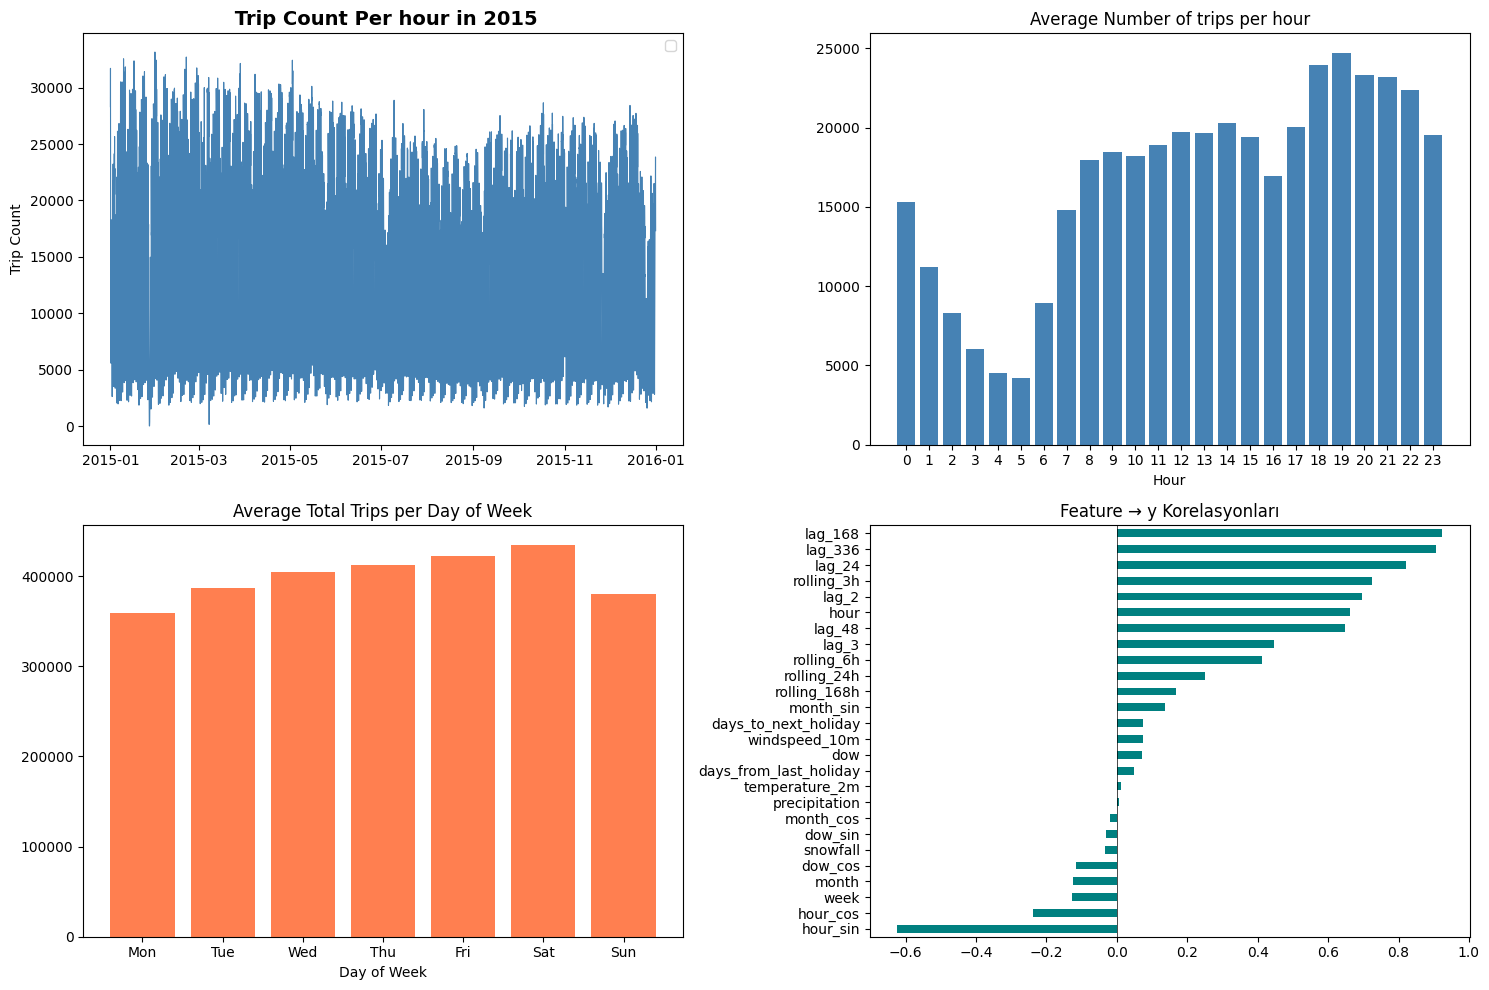

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(h.index, h["y"], linewidth=0.8, color="steelblue")

axes[0, 0].set_title(" Trip Count Per hour in 2015", fontsize=14, fontweight="bold")
axes[0, 0].legend()
axes[0, 0].set_ylabel("Trip Count")

hourly_avg = h.groupby("hour")["y"].mean()
axes[0, 1].bar(hourly_avg.index, hourly_avg.values, color="steelblue")
axes[0, 1].set_title("Average Number of trips per hour")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_xticks(range(0, 24))

daily_totals = h["y"].resample("D").sum()
daily_avg_per_dow = daily_totals.groupby(daily_totals.index.dayofweek).mean()
axes[1, 0].bar(daily_avg_per_dow.index, daily_avg_per_dow.values, color="coral")
axes[1, 0].set_title("Average Total Trips per Day of Week")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

feature_cols = [c for c in h.columns if c != "y"]
corr_with_y = h[feature_cols].corrwith(h["y"]).sort_values(ascending=True)
corr_with_y.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Feature → y Korelasyonları")
axes[1, 1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

In [11]:
# En yüksek değerleri bul
print(h["y"].nlargest(10))

2015-11-01 01:00:00    45849
2015-01-30 19:00:00    33152
2015-02-20 19:00:00    32709
2015-01-09 19:00:00    32553
2015-05-02 19:00:00    32427
2015-01-31 19:00:00    32426
2015-01-16 19:00:00    32369
2015-03-28 23:00:00    32143
2015-01-30 20:00:00    31934
2015-01-10 23:00:00    31835
Name: y, dtype: int64


In [12]:
print(h_16["y"].nlargest(5))

2016-11-06 01:00:00    33898
2016-04-29 19:00:00    29762
2016-03-04 19:00:00    28757
2016-04-08 19:00:00    28655
2016-02-11 19:00:00    28611
Name: y, dtype: int64


In [13]:
# 2015 düzeltmesi
h.loc["2015-11-01 01:00:00", "y"] = (
    h.loc["2015-11-01 00:00:00", "y"] + 
    h.loc["2015-11-01 02:00:00", "y"]
) / 2

# 2016 düzeltmesi
h_16.loc["2016-11-06 01:00:00", "y"] = (
    h_16.loc["2016-11-06 00:00:00", "y"] + 
    h_16.loc["2016-11-06 02:00:00", "y"]
) / 2

In [ ]:
# Cyclical encoding
h["hour_sin"] = np.sin(2 * np.pi * h["hour"] / 24)
h["hour_cos"] = np.cos(2 * np.pi * h["hour"] / 24)
h["dow_sin"]  = np.sin(2 * np.pi * h["dow"] / 7)
h["dow_cos"]  = np.cos(2 * np.pi * h["dow"] / 7)
h["month_sin"]=np.sin(2*np.pi*h["month"]/12)
h["month_cos"]=np.cos(2*np.pi*h["month"]/12)

# Lag features
# h["lag_1"]  = h["y"].shift(1)
h["lag_2"]  = h["y"].shift(2)
h["lag_3"]  = h["y"].shift(3)
h["lag_24"] = h["y"].shift(24)
h["lag_48"] = h["y"].shift(48)
h["lag_168"] = h["y"].shift(168)
h["lag_336"]=h["y"].shift(336)
# Rolling averages
h["rolling_3h"]  = h["y"].shift(1).rolling(3).mean()
h["rolling_6h"]  = h["y"].shift(1).rolling(6).mean()
h["rolling_24h"] = h["y"].shift(1).rolling(24).mean()
h["rolling_168h"] = h["y"].shift(1).rolling(168).mean()
import holidays
us_holidays = holidays.US(state='NY', years=[2015, 2016])

h["days_to_next_holiday"]  = h.index.map(
    lambda ts: min([(h - ts.date()).days for h in us_holidays if (h - ts.date()).days >= 0], default=365)
)
h["days_from_last_holiday"] = h.index.map(
    lambda ts: min([(ts.date() - h).days for h in us_holidays if (ts.date() - h).days >= 0], default=365)
)





# Cyclical encoding
h_16["hour_sin"] = np.sin(2 * np.pi * h_16["hour"] / 24)
h_16["hour_cos"] = np.cos(2 * np.pi * h_16["hour"] / 24)
h_16["dow_sin"]  = np.sin(2 * np.pi * h_16["dow"] / 7)
h_16["dow_cos"]  = np.cos(2 * np.pi * h_16["dow"] / 7)
h_16["month_sin"]=np.sin(2*np.pi*h_16["month"]/12)
h_16["month_cos"]=np.cos(2*np.pi*h_16["month"]/12)

# Lag features
#h_16["lag_1"]  = h_16["y"].shift(1)
h_16["lag_2"]  = h_16["y"].shift(2)
h_16["lag_3"]  = h_16["y"].shift(3)
h_16["lag_24"] = h_16["y"].shift(24)
h_16["lag_48"] = h_16["y"].shift(48)
h_16["lag_168"] = h_16["y"].shift(168)
h_16["lag_336"]=h_16["y"].shift(336)
# Rolling averages
h_16["rolling_3h"]  = h_16["y"].shift(1).rolling(3).mean()
h_16["rolling_6h"]  = h_16["y"].shift(1).rolling(6).mean()
h_16["rolling_24h"] = h_16["y"].shift(1).rolling(24).mean()
h_16["rolling_168h"] = h_16["y"].shift(1).rolling(168).mean()
us_holidays = holidays.US(state='NY', years=[2016, 2017])

h_16["days_to_next_holiday"]  = h_16.index.map(
    lambda ts: min([(h_16 - ts.date()).days for h_16 in us_holidays if (h_16 - ts.date()).days >= 0], default=365)
)
h_16["days_from_last_holiday"] = h_16.index.map(
    lambda ts: min([(ts.date() - h_16).days for h_16 in us_holidays if (ts.date() - h_16).days >= 0], default=365)
)



h=h.loc["2015-01-01":]
h_16=h_16.loc["2016-01-01":]
feature_cols = [c for c in h.columns if c != "y"]
X_train, y_train = h[feature_cols], h["y"]
X_test,  y_test  = h_16[feature_cols], h_16["y"]



In [ ]:
import requests

base_params = {
    "start_date": "2015-01-01",
    "end_date": "2015-12-31",
    "hourly": "temperature_2m,precipitation,snowfall,windspeed_10m",
    "timezone": "America/New_York"
}

stations = {
    "manhattan": (40.7128, -74.0060),
    "jfk":       (40.6413, -73.7781),
    "laguardia": (40.7769, -73.8740),
}

dfs = []
for name, (lat, lon) in stations.items():
    r = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={**base_params, "latitude": lat, "longitude": lon}
    ).json()
    df_w = pd.DataFrame(r["hourly"])
    df_w["time"] = pd.to_datetime(df_w["time"])
    df_w = df_w.set_index("time")
    dfs.append(df_w)

weather = sum(dfs) / len(dfs)
h = h.join(weather)


dfs_16 = []
for name, (lat, lon) in stations.items():
    r = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={**base_params, "start_date": "2016-01-01", "end_date": "2016-12-31", "latitude": lat, "longitude": lon}
    ).json()
    df_w = pd.DataFrame(r["hourly"])
    df_w["time"] = pd.to_datetime(df_w["time"])
    df_w = df_w.set_index("time")
    dfs_16.append(df_w)

weather_16 = sum(dfs_16) / len(dfs_16)
h_16 = h_16.join(weather_16)

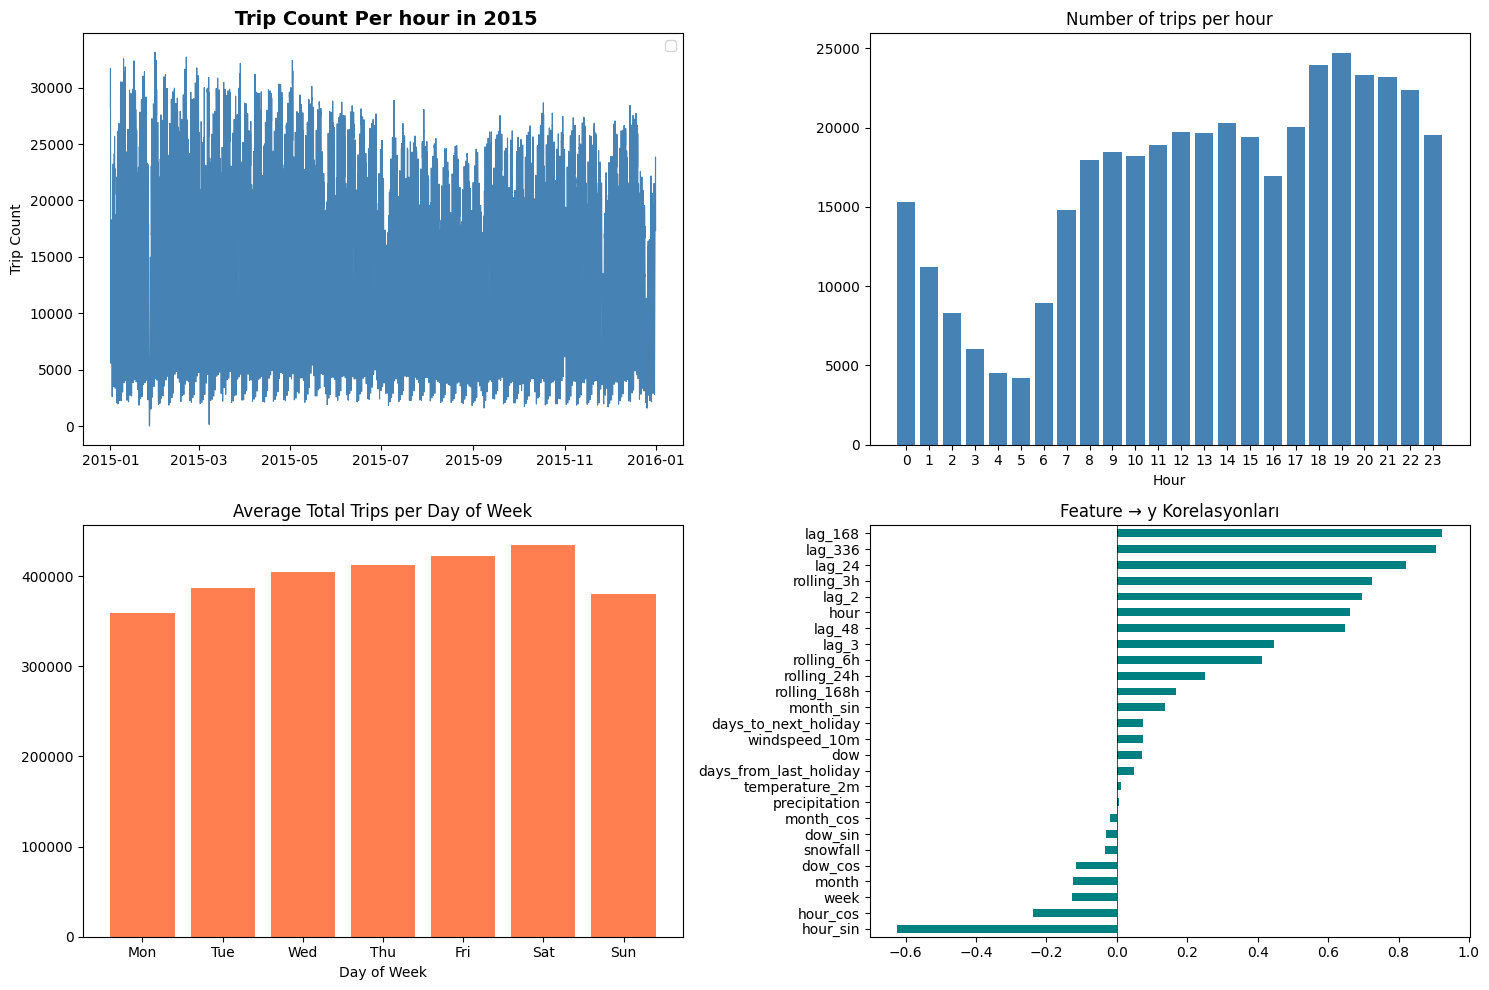

In [73]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(h.index, h["y"], linewidth=0.8, color="steelblue")

axes[0, 0].set_title(" Trip Count Per hour in 2015", fontsize=14, fontweight="bold")
axes[0, 0].legend()
axes[0, 0].set_ylabel("Trip Count")

hourly_avg = h.groupby("hour")["y"].mean()
axes[0, 1].bar(hourly_avg.index, hourly_avg.values, color="steelblue")
axes[0, 1].set_title("Number of trips per hour")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_xticks(range(0, 24))

daily_totals = h["y"].resample("D").sum()
daily_avg_per_dow = daily_totals.groupby(daily_totals.index.dayofweek).mean()
axes[1, 0].bar(daily_avg_per_dow.index, daily_avg_per_dow.values, color="coral")
axes[1, 0].set_title("Average Total Trips per Day of Week")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

feature_cols = [c for c in h.columns if c != "y"]
corr_with_y = h[feature_cols].corrwith(h["y"]).sort_values(ascending=True)
corr_with_y.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Feature → y Korelasyonları")
axes[1, 1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()


train = h.copy()
test  = h_16.copy()

feature_cols = [c for c in h.columns if c != "y"]

X_train = train[feature_cols]
y_train = train["y"]
X_test  = test[feature_cols]
y_test  = test["y"]




In [17]:
X_train.size,y_train.size,X_test.size,y_test.size

(227760, 8760, 228384, 8784)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# === EVALUATION FUNCTION ===
def evaluate(name, y_true, y_pred):
    # Prevent negative predictions
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, None)  
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    # sMAPE calculation
    smape = 200 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    
    print(f"{name:35s} | MAE: {mae:>7.0f} | RMSE: {rmse:>7.0f} | R²: {r2:.4f} | sMAPE: {smape:.1f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "sMAPE": smape}



## LIGHTGBM REGRESSOR

In [36]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

def objective(trial):
    param = {
    "objective": "poisson",
    "metric": "rmse",
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
    "n_estimators": trial.suggest_int("n_estimators", 700, 1200),
    "num_leaves": trial.suggest_int("num_leaves", 40, 80),
    "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 50),
    "subsample": trial.suggest_float("subsample", 0.7, 0.9),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
    "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 1.0, log=True),
    }

    model = lgb.LGBMRegressor(**param)
    tscv = TimeSeriesSplit(n_splits=5,gap=168)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=tscv, 
                             scoring="neg_root_mean_squared_error",
                             n_jobs=-1)
    return -scores.mean()+scores.std()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100,timeout=900) 

print("Best Parameters:", study.best_params)
print("Lowest RMSE:", study.best_value)

Best Parameters: {'learning_rate': 0.011111491971339326, 'n_estimators': 915, 'num_leaves': 73, 'min_data_in_leaf': 27, 'subsample': 0.8700007024509795, 'colsample_bytree': 0.7098754593727056, 'reg_lambda': 0.04316426085469324}
Lowest RMSE: 1385.71488352771


In [37]:

best_params = study.best_params
best_params['objective'] = 'poisson' 
best_params['random_state'] = 42

final_lgbm = lgb.LGBMRegressor(**best_params)
final_lgbm.fit(X_train, y_train)

y_pred_lgbm = np.clip(final_lgbm.predict(X_test), 0, None)
lgbm_optuna_Result = evaluate("LightGBM Tuned with Optuna", y_test, y_pred_lgbm)
lgbm_optuna_Result

[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3563
[LightGBM] [Info] Number of data points in the train set: 8760, number of used features: 26
[LightGBM] [Info] Start training from score 9.721270
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
LightGBM Tuned with Optuna          | MAE:     833 | RMSE:    1242 | R²: 0.9657 | sMAPE: 7.1%


{'model': 'LightGBM Tuned with Optuna',
 'MAE': 832.7942188987712,
 'RMSE': np.float64(1242.0483867481544),
 'R2': 0.9656719811385811,
 'sMAPE': np.float64(7.140581997344696)}

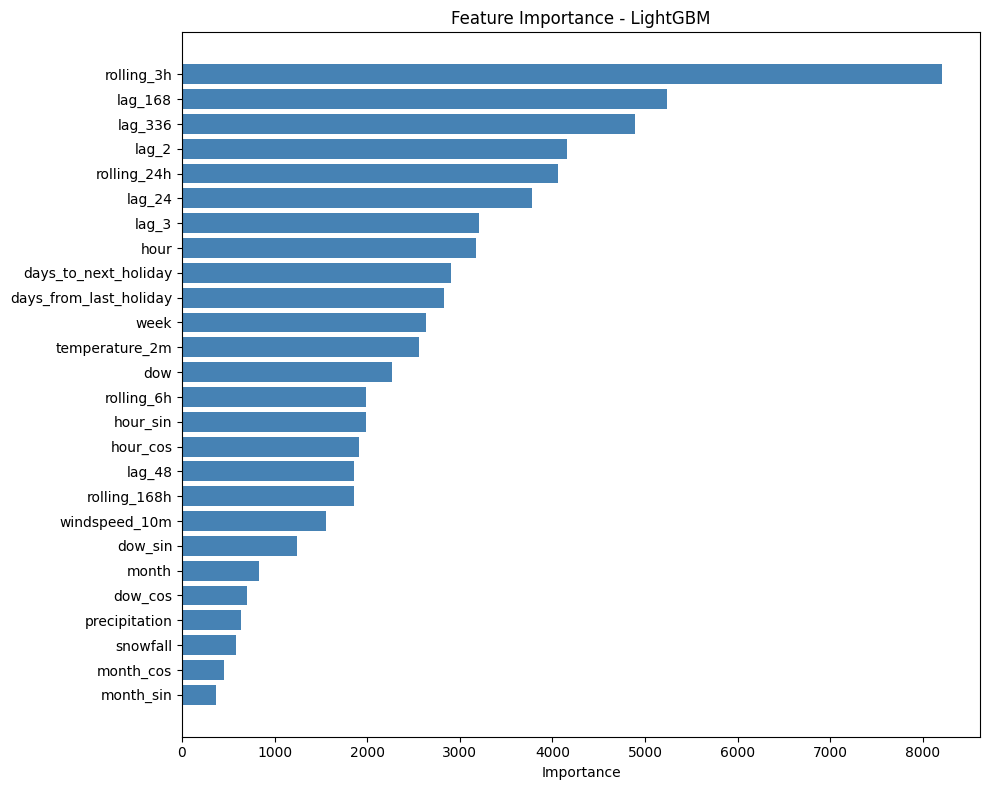

In [38]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_lgbm.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance - LightGBM')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## XGBOOST REGRESSOR

In [22]:
from xgboost import XGBRegressor


model_xgb= XGBRegressor(objective='count:poisson', random_state=42, verbosity=0)


In [23]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

def objective(trial):
    param = {
        "objective": "count:poisson",
        "verbosity": 0,
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 100),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0), 
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = XGBRegressor(**param)
    tscv = TimeSeriesSplit(n_splits=5,gap=168)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=tscv, 
                             scoring="neg_root_mean_squared_error",
                             )
    return -scores.mean()+scores.std()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100,timeout=900) 

print("Best Parameters:", study.best_params)
print("Lowest RMSE:", study.best_value)

[I 2026-03-05 11:23:02,349] A new study created in memory with name: no-name-f75333df-e15b-4cb3-a840-e5740e0e46fc
[I 2026-03-05 11:23:23,220] Trial 0 finished with value: 1368.787386057938 and parameters: {'learning_rate': 0.0201330551333213, 'n_estimators': 1344, 'min_child_weight': 76, 'gamma': 0.7395508162720993, 'max_depth': 7, 'subsample': 0.7675054077340066, 'colsample_bytree': 0.7789537610676207, 'colsample_bylevel': 0.8528180888921634, 'reg_alpha': 0.0015227318646557054, 'reg_lambda': 0.01638609042207701}. Best is trial 0 with value: 1368.787386057938.
[I 2026-03-05 11:23:34,131] Trial 1 finished with value: 1419.5016121947178 and parameters: {'learning_rate': 0.048999176182491555, 'n_estimators': 1051, 'min_child_weight': 72, 'gamma': 4.113635961588099, 'max_depth': 8, 'subsample': 0.9665133311417624, 'colsample_bytree': 0.7758393238576047, 'colsample_bylevel': 0.9478574054938848, 'reg_alpha': 0.3530702075969568, 'reg_lambda': 2.2739262159163953}. Best is trial 0 with value: 1

Best Parameters: {'learning_rate': 0.0152544270300264, 'n_estimators': 1268, 'min_child_weight': 43, 'gamma': 0.006633962558190973, 'max_depth': 9, 'subsample': 0.7119523078750358, 'colsample_bytree': 0.7457536488803032, 'colsample_bylevel': 0.6117912410527973, 'reg_alpha': 0.00485196523724597, 'reg_lambda': 0.10418156171221903}
Lowest RMSE: 1328.3711698275201


In [24]:
best_params = study.best_params
best_params['objective'] = 'count:poisson' 
best_params['random_state'] = 42

final_XG = XGBRegressor(**best_params)
final_XG.fit(X_train, y_train)

y_pred_xg = np.clip(final_XG.predict(X_test), 0, None)
xgb_optuna_Result = evaluate("XGBoost Tuned with Optuna", y_test, y_pred_xg)
xgb_optuna_Result

XGBoost Tuned with Optuna           | MAE:     777 | RMSE:    1153 | R²: 0.9704 | sMAPE: 6.4%


{'model': 'XGBoost Tuned with Optuna',
 'MAE': 777.2918532359362,
 'RMSE': np.float64(1153.4569909824718),
 'R2': 0.9703943554117052,
 'sMAPE': np.float64(6.415921394875701)}

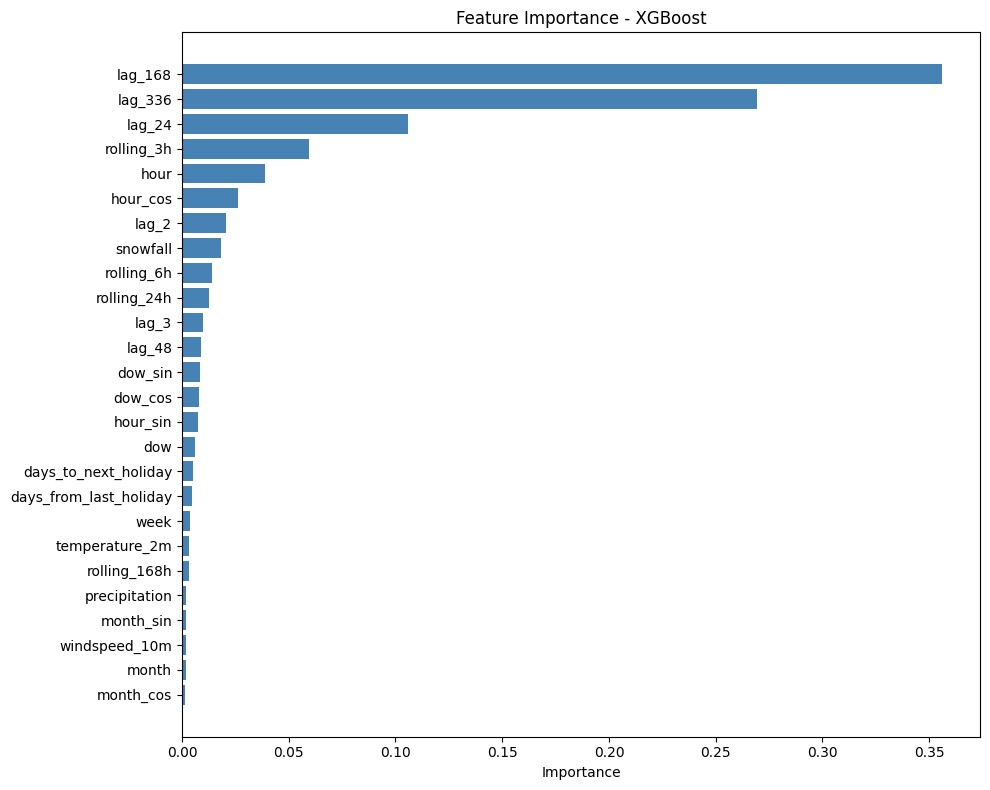

In [25]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_XG.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## PROPHET

In [26]:
from prophet import Prophet

In [ ]:
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
regressors = [
    "lag_2", "lag_3",
    "lag_24", "lag_48", 
    "lag_168", "lag_336",
    "rolling_3h", "rolling_6h", "rolling_24h", "rolling_168h",
    "temperature_2m", "precipitation", "snowfall", "windspeed_10m",
    "days_to_next_holiday", "days_from_last_holiday"
]

prophet_df = h[["y"] + regressors].copy()
prophet_df["ds"] = h.index
prophet_df = prophet_df.dropna().reset_index(drop=True)

prophet_test = h_16[["y"] + regressors].copy()
prophet_test["ds"] = h_16.index
prophet_test = prophet_test.dropna().reset_index(drop=True)

def objective(trial):
    param = {
        "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
        "holidays_prior_scale": trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
        "n_changepoints": trial.suggest_int("n_changepoints", 10, 50),
        "changepoint_range": trial.suggest_float("changepoint_range", 0.7, 0.95),
    }

    tscv = TimeSeriesSplit(n_splits=5,gap=168)
    rmses = []

    for train_idx, val_idx in tscv.split(prophet_df):
        train_fold = prophet_df.iloc[train_idx]
        val_fold   = prophet_df.iloc[val_idx]

        model = Prophet(**param, daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
        for reg in regressors:       
            model.add_regressor(reg)
        model.fit(train_fold)

        future = val_fold[["ds"] + regressors]  
        forecast = model.predict(future)
        y_pred = np.clip(forecast["yhat"].values, 0, None)

        rmse = np.sqrt(np.mean((val_fold["y"].values - y_pred) ** 2))
        rmses.append(rmse)

    return np.mean(rmses)+np.std(rmses)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, timeout=900)
print("Best Parameters:", study.best_params)
print("Lowest RMSE:", study.best_value)
# Final model
final_prophet = Prophet(
    **study.best_params,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
for reg in regressors:                 
    final_prophet.add_regressor(reg)
final_prophet.fit(prophet_df)

future = prophet_test[["ds"] + regressors]  
forecast = final_prophet.predict(future)

y_pred_prophet = np.clip(forecast["yhat"].values, 0, None)
prophet_Result = evaluate("Prophet with Optuna", prophet_test["y"].values, y_pred_prophet)

11:38:46 - cmdstanpy - INFO - Chain [1] start processing
11:38:46 - cmdstanpy - INFO - Chain [1] done processing
11:38:47 - cmdstanpy - INFO - Chain [1] start processing
11:38:47 - cmdstanpy - INFO - Chain [1] done processing
11:38:48 - cmdstanpy - INFO - Chain [1] start processing
11:38:48 - cmdstanpy - INFO - Chain [1] done processing
11:38:49 - cmdstanpy - INFO - Chain [1] start processing
11:38:50 - cmdstanpy - INFO - Chain [1] done processing
11:38:51 - cmdstanpy - INFO - Chain [1] start processing
11:38:51 - cmdstanpy - INFO - Chain [1] done processing
11:38:52 - cmdstanpy - INFO - Chain [1] start processing
11:38:52 - cmdstanpy - INFO - Chain [1] done processing
11:38:53 - cmdstanpy - INFO - Chain [1] start processing
11:38:53 - cmdstanpy - INFO - Chain [1] done processing
11:38:54 - cmdstanpy - INFO - Chain [1] start processing
11:38:55 - cmdstanpy - INFO - Chain [1] done processing
11:38:56 - cmdstanpy - INFO - Chain [1] start processing
11:38:58 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.15226208692336113, 'seasonality_prior_scale': 0.010227176341065843, 'holidays_prior_scale': 3.758330072399147, 'n_changepoints': 17, 'changepoint_range': 0.7595382178168183}
Lowest RMSE: 1705.7487978822146


11:53:52 - cmdstanpy - INFO - Chain [1] start processing
11:53:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet with Optuna                 | MAE:     999 | RMSE:    1366 | R²: 0.9585 | sMAPE: 9.6%


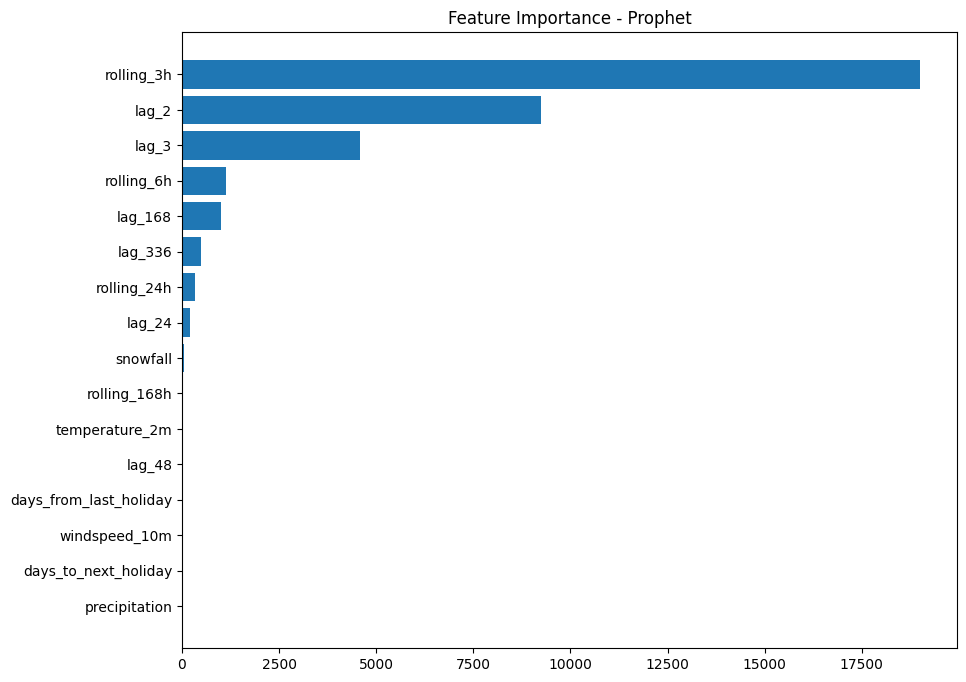

In [31]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class ProphetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, ds_values, regressors):
        self.model = model
        self.ds_values = ds_values
        self.regressors = regressors

    def fit(self, X, y=None):
        return self  

    def predict(self, X):
        df_temp = pd.DataFrame(X, columns=self.regressors)
        df_temp["ds"] = self.ds_values[:len(X)]
        forecast = self.model.predict(df_temp)
        return np.clip(forecast["yhat"].values, 0, None)


wrapper = ProphetWrapper(
    final_prophet,
    prophet_test["ds"].values,
    regressors
)

perm = permutation_importance(
    wrapper,
    prophet_test[regressors].values,
    prophet_test["y"].values,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": regressors,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Feature Importance - Prophet")
plt.show()

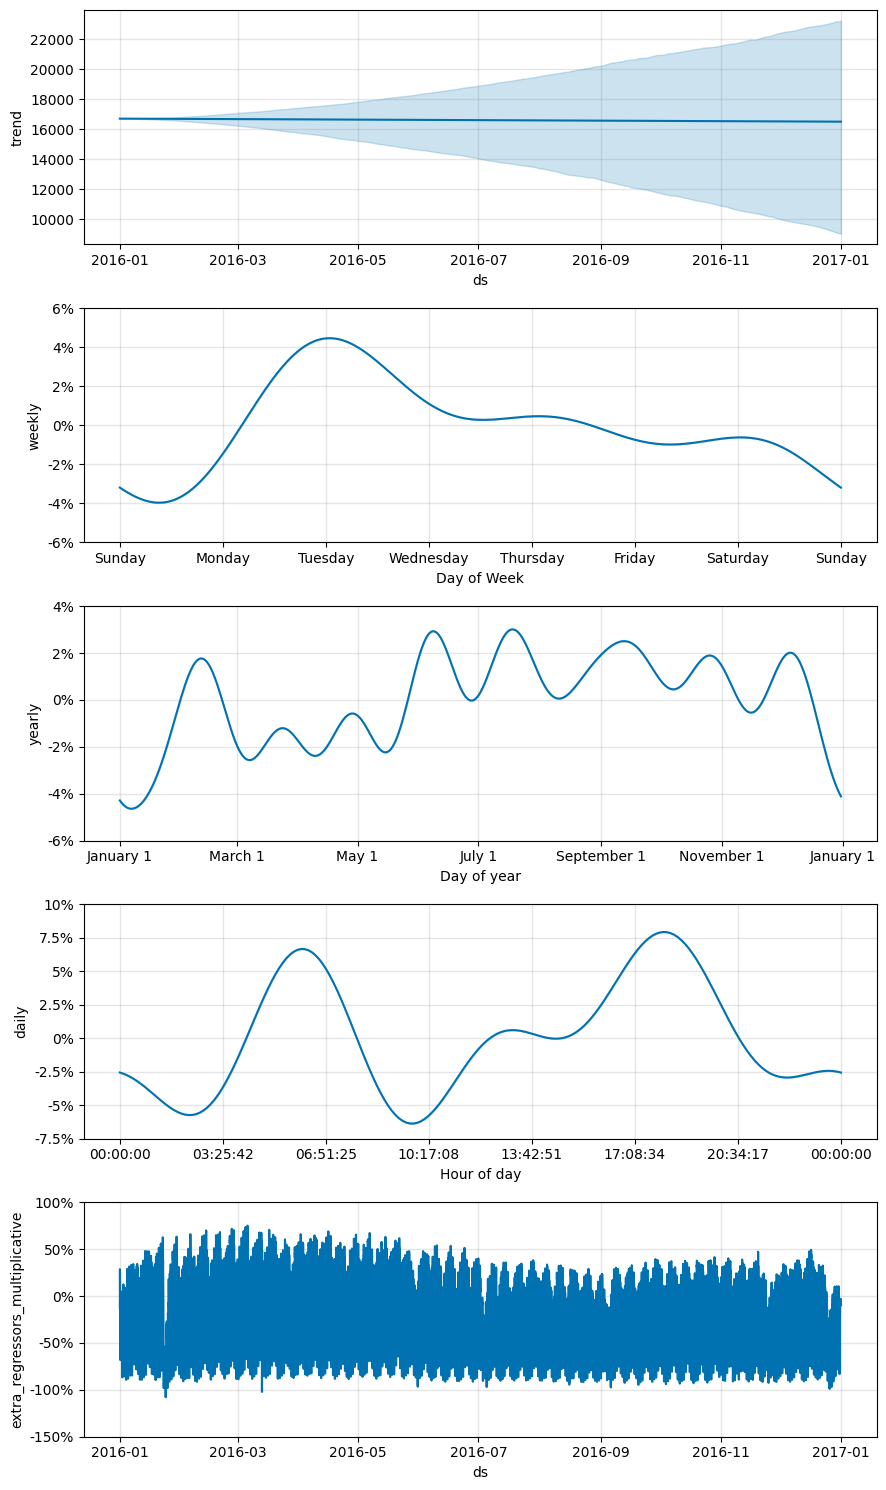

In [32]:
fig = final_prophet.plot_components(forecast)
plt.show()

## RIDGE

In [ ]:
from sklearn.linear_model import Ridge


def objective(trial):
    param = {
        "alpha": trial.suggest_float("alpha", 0.1, 10.0, log=True),
    }

    model = Ridge(**param)
    tscv = TimeSeriesSplit(n_splits=5,gap=168)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=tscv, 
                             scoring="neg_root_mean_squared_error",
                             n_jobs=-1)
    return -scores.mean()+scores.std()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, timeout=900)

print("Best Parameters:", study.best_params)
print("Lowest RMSE:", study.best_value)

Best Parameters: {'alpha': 0.1000925836589681}
Lowest RMSE: 2003.5491453970599


In [35]:

best_params = study.best_params

final_ridge = Ridge(**best_params)
final_ridge.fit(X_train, y_train)

y_pred_ridge = np.clip(final_ridge.predict(X_test), 0, None)
ridge_optuna_Result = evaluate("Ridge Tuned with Optuna", y_test, y_pred_ridge)


Ridge Tuned with Optuna             | MAE:    1028 | RMSE:    1454 | R²: 0.9529 | sMAPE: 9.8%


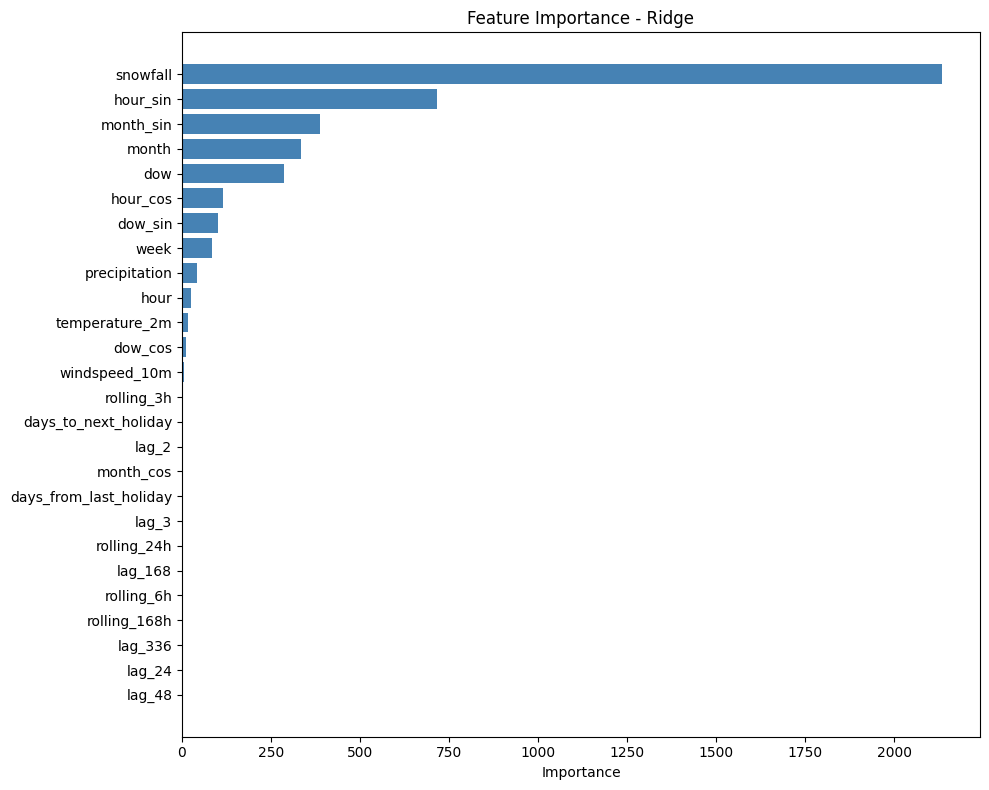

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(final_ridge.coef_)
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance - Ridge')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## RESULTS

In [39]:
Result= pd.DataFrame([lgbm_optuna_Result,xgb_optuna_Result, prophet_Result, ridge_optuna_Result])
Result

,model,MAE,RMSE,R2,sMAPE
0,LightGBM Tuned with Optuna,832.794219,1242.048387,0.965672,7.140582
1,XGBoost Tuned with Optuna,777.291853,1153.456991,0.970394,6.415921
2,Prophet with Optuna,999.460628,1365.945052,0.958482,9.622757
3,Ridge Tuned with Optuna,1028.079552,1454.452478,0.952927,9.765187


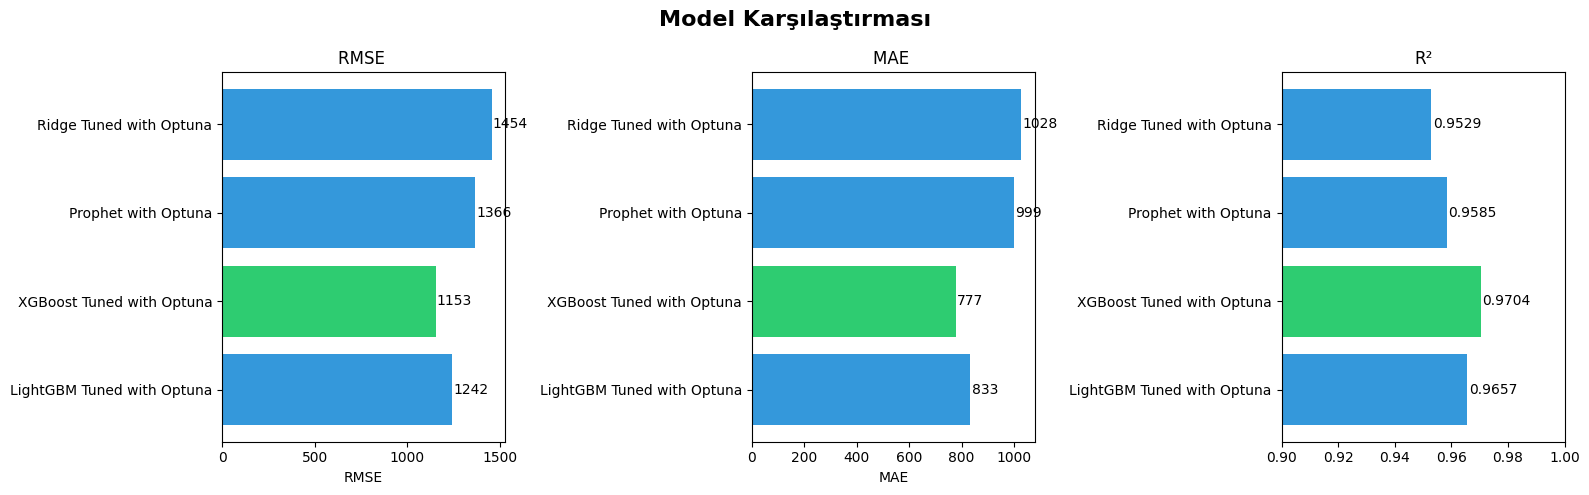

<Figure size 640x480 with 0 Axes>

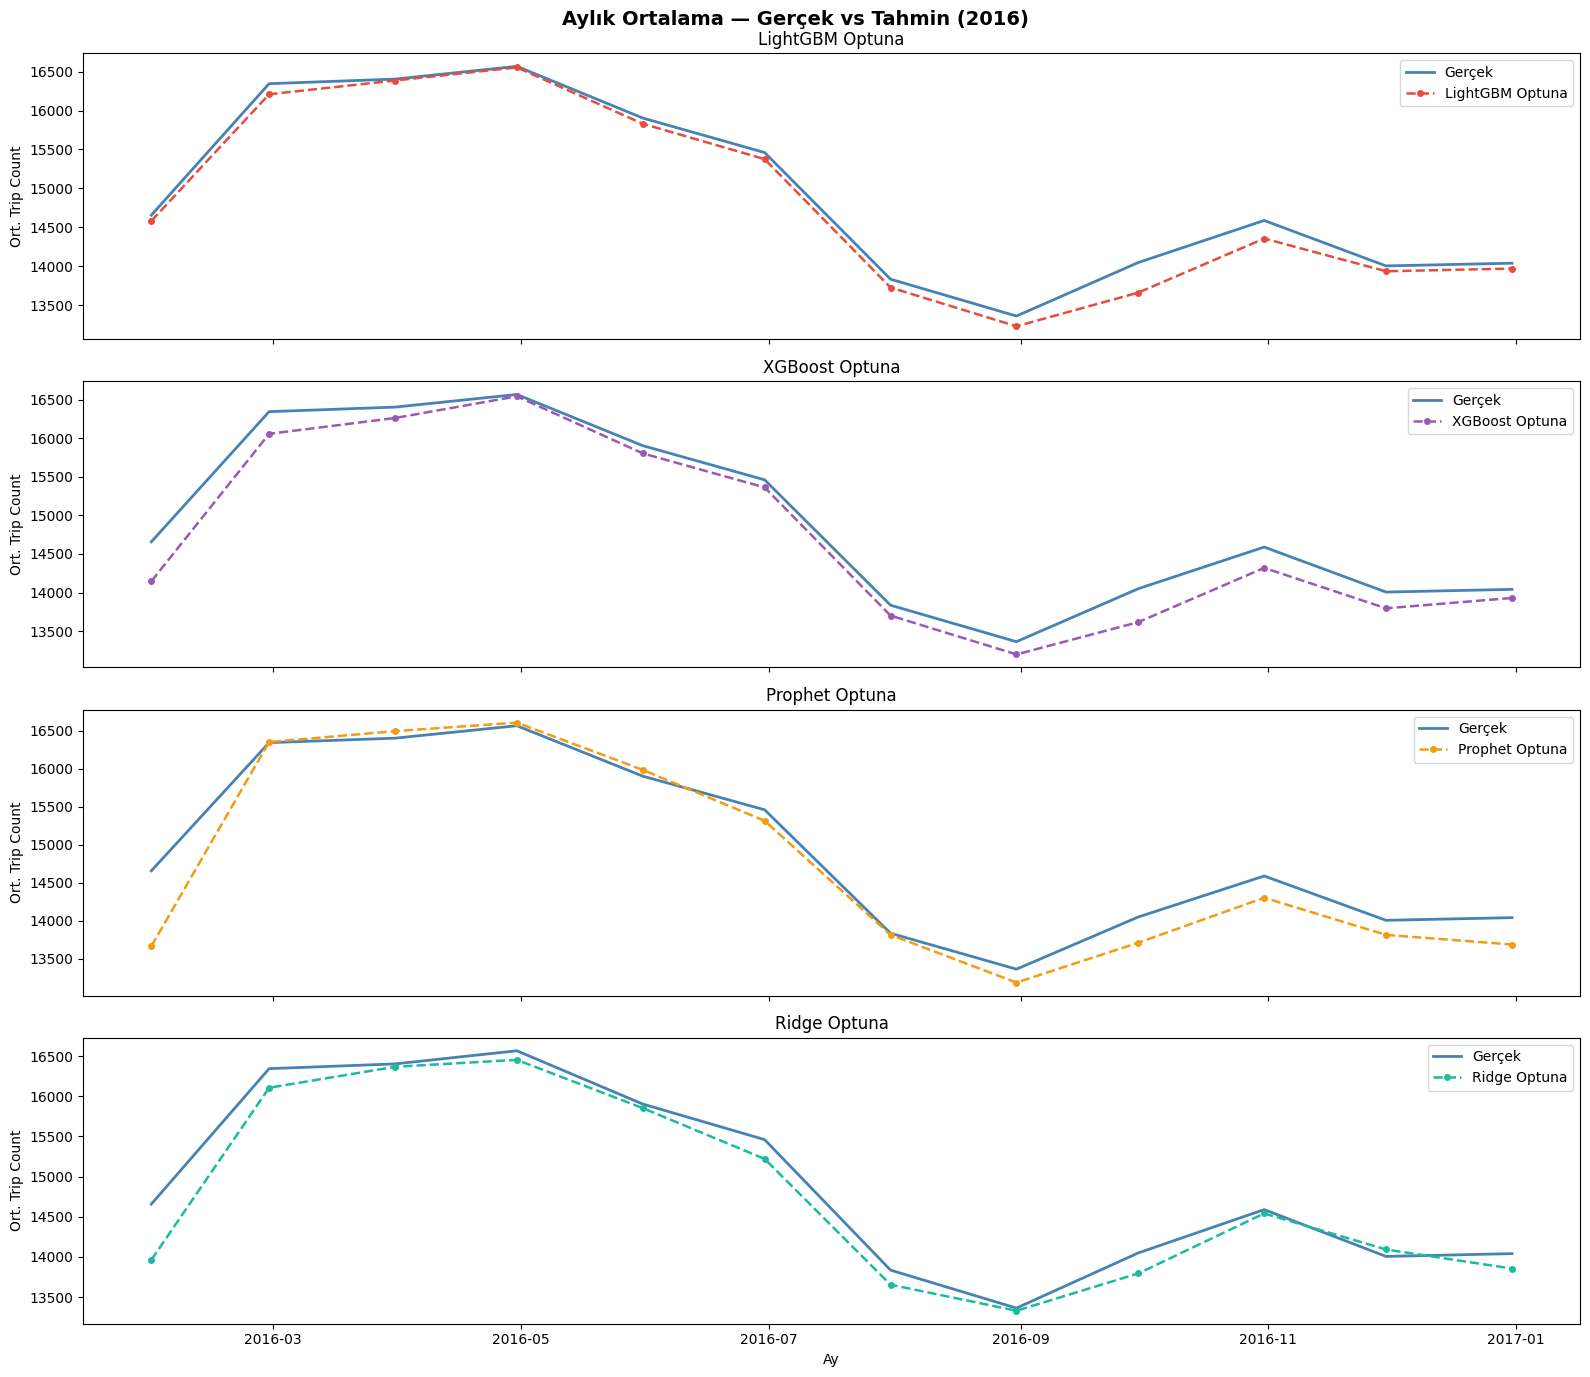

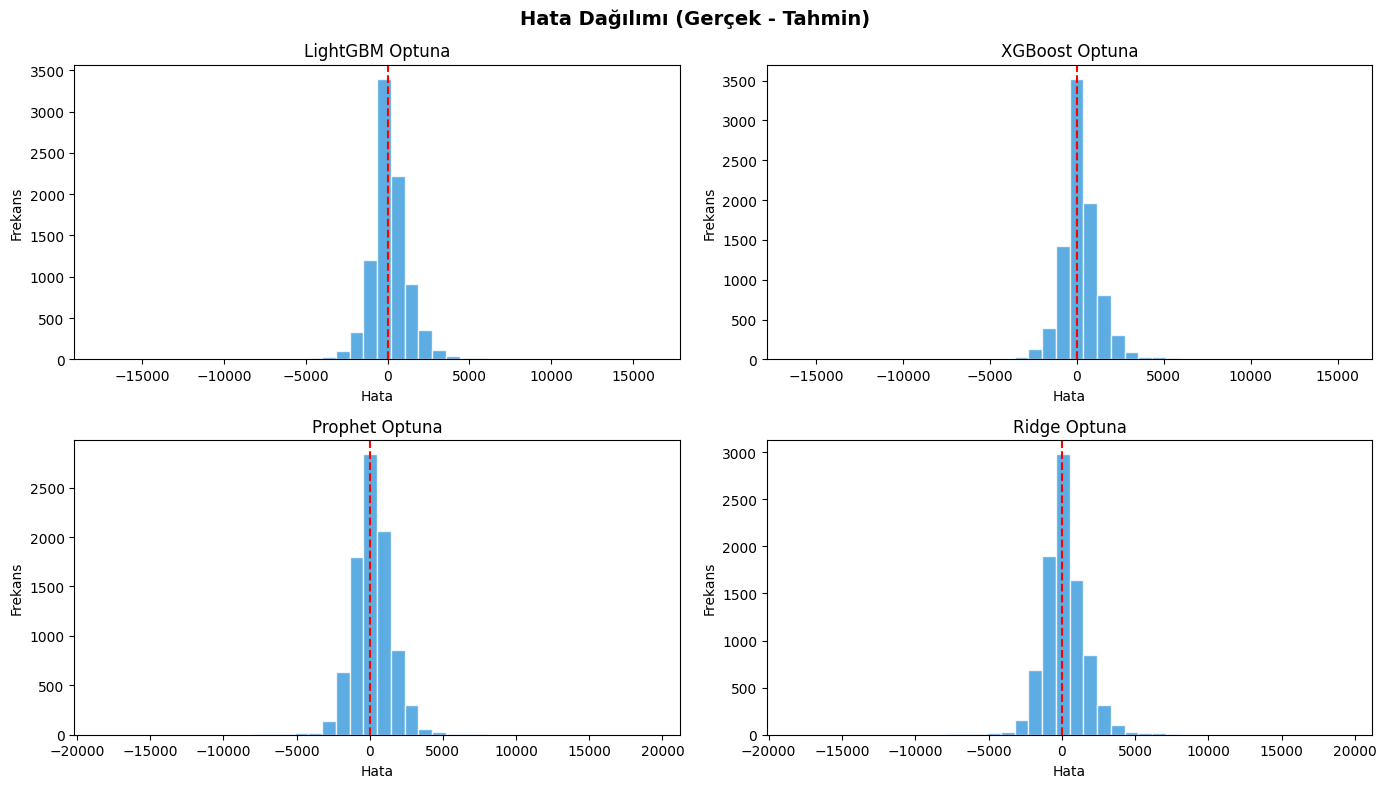

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Model Karşılaştırma Barplot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Karşılaştırması", fontsize=16, fontweight="bold")

models = Result["model"].tolist()
colors = ["#2ecc71" if r == min(Result["RMSE"]) else "#3498db" for r in Result["RMSE"]]

# RMSE
axes[0].barh(models, Result["RMSE"], color=colors)
axes[0].set_title("RMSE ")
axes[0].set_xlabel("RMSE")
for i, v in enumerate(Result["RMSE"]):
    axes[0].text(v + 5, i, f"{v:.0f}", va="center")

# MAE
colors_mae = ["#2ecc71" if r == min(Result["MAE"]) else "#3498db" for r in Result["MAE"]]
axes[1].barh(models, Result["MAE"], color=colors_mae)
axes[1].set_title("MAE ")
axes[1].set_xlabel("MAE")
for i, v in enumerate(Result["MAE"]):
    axes[1].text(v + 5, i, f"{v:.0f}", va="center")

# R²
colors_r2 = ["#2ecc71" if r == max(Result["R2"]) else "#3498db" for r in Result["R2"]]
axes[2].barh(models, Result["R2"], color=colors_r2)
axes[2].set_title("R²")
axes[2].set_xlim(0.9, 1.0)
for i, v in enumerate(Result["R2"]):
    axes[2].text(v + 0.0005, i, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()



plt.tight_layout()
plt.show()
# --- 2. Gerçek vs Tahmin (ilk 7 gün) ---
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle("Aylık Ortalama — Gerçek vs Tahmin (2016)", fontsize=14, fontweight="bold")

test_index = pd.DatetimeIndex(prophet_test["ds"])

monthly_data = {
    "LightGBM Optuna":  y_pred_lgbm,
    "XGBoost Optuna":   y_pred_xg,
    "Prophet Optuna":   y_pred_prophet,
    "Ridge Optuna":     y_pred_ridge,
}

colors_line = ["#e74c3c", "#9b59b6", "#f39c12", "#1abc9c"]

# Gerçek değerleri aylık ortala
actual_monthly = pd.Series(y_test.values, index=test_index).resample("ME").mean()

for ax, (name, preds), color in zip(axes, monthly_data.items(), colors_line):
    pred_monthly = pd.Series(preds, index=test_index).resample("ME").mean()
    ax.plot(actual_monthly.index, actual_monthly.values, label="Gerçek", color="steelblue", linewidth=2)
    ax.plot(pred_monthly.index, pred_monthly.values, label=name, color=color, linewidth=1.8, linestyle="--", marker="o", markersize=4)
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.set_ylabel("Ort. Trip Count")

axes[-1].set_xlabel("Ay")
plt.tight_layout()
plt.show()

# --- 3. Hata Dağılımı ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Hata Dağılımı (Gerçek - Tahmin)", fontsize=14, fontweight="bold")

error_data = {
    "LightGBM Optuna": y_test - y_pred_lgbm,
    "XGBoost Optuna": y_test - y_pred_xg,
    "Prophet Optuna": y_test - y_pred_prophet,
    "Ridge Optuna": y_test - y_pred_ridge
}

for ax, (name, errors) in zip(axes.flatten(), error_data.items()):
    ax.hist(errors, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Hata")
    ax.set_ylabel("Frekans")

plt.tight_layout()
plt.show()

In [41]:
print("2015 ortalama:", h["y"].mean())
print("2016 ortalama:", h_16["y"].mean())
print("Fark:", h_16["y"].mean() - h["y"].mean())

2015 ortalama: 16668.399315068495
2016 ortalama: 14926.486908014573
Fark: -1741.912407053922
